## Import

In [6]:
import os
import time
import numpy as np
import scipy.linalg as linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
#import preprocess


device = 'cuda:0'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Experiment settings

In [ ]:
mi_level = "mid"
mi_array = {'low':1, 'mid':3, 'high':7, 'very_high':9}
latent = False

mi = mi_array[mi_level]

## Data generation

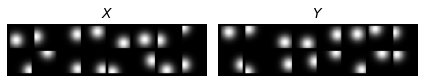

In [ ]:
from image import image_dataset

X, Y = image_dataset.generate_gaussian_plot(mi=mi, n_samples=10000, device=device)

n, d = X.size()[0], 2*X.size()[1]

image_dataset.visualize_images(X, Y)

## Dimensionality reduction

In [8]:
from dr.Autoencoder import Autoencoder
from utils import utils_os


# [A]. Train autoencoder to compress data
if not os.path.isfile(f'results/images/gaussian_ae_X_{mi_level}.npy'):
    print('compression does not exist; train autoencoder')

    ae = Autoencoder(x_dim=d//2, y_dim=d//2, latent_size=8, alpha=1, lam=0)

    ae.to(device)
    X, Y = X.to(device).float(), Y.to(device).float()
    ae.learn(X, Y)
    
    XX, YY = ae.encode(X, Y)
    XX, YY = XX.clone().detach(), YY.clone().detach()

    utils_os.save_object('results/images', f'gaussian_ae_X_{mi_level}.npy', XX.detach().cpu().numpy())
    utils_os.save_object('results/images', f'gaussian_ae_Y_{mi_level}.npy', YY.detach().cpu().numpy())

# [B]. File exist; load previous compression
else:
    print('compression already exist; loading .npy files')

    XX = utils_os.load_object('results/images', f'gaussian_ae_X_{mi_level}.npy')
    YY = utils_os.load_object('results/images', f'gaussian_ae_Y_{mi_level}.npy')
    XX, YY = torch.Tensor(XX).clone().detach().to(device), torch.Tensor(YY).clone().detach().to(device)

n, d = torch.cat([XX, YY], dim=1).size()

compression already exist; loading .npy files


## MI estimation

In [9]:
class Hyperparams(object):
    def __init__(self): 
        self.critic = 'neural'                # ('neural', 'quadratic')
        self.lr = 5e-4
        self.bs = 500
        self.n_bridges = 4
        self.wd = 1e-5
        self.max_iteration = 1250
        
hyperparams=Hyperparams()

architecture_critic = [d, 500, 500, 500, 1]

In [15]:
## Mutual information neural diffusion estimate (MINDE)
from estimators.MINDE import MINDE

hyperparams.t_patience = 500
hyperparams.dim = d//2
hyperparams.device = device
hyperparams.importance_sampling = True

estimator = MINDE(None, None, None, hyperparams)

estimator.to(device)
estimator.learn(XX, YY)

print('true MI:', mi)
print('est MI:', estimator.MI(XX, YY))

finished: t= 0 loss= 1.011170744895935 loss val= 1.477656602859497 best val loss= 1.477656602859497 best t= 0
finished: t= 63 loss= 0.32781004905700684 loss val= 0.36899566650390625 best val loss= 0.3047524392604828 best t= 50
finished: t= 126 loss= 0.3002510666847229 loss val= 0.2529837191104889 best val loss= 0.2529837191104889 best t= 126
finished: t= 189 loss= 0.24458056688308716 loss val= 0.24806153774261475 best val loss= 0.2465895116329193 best t= 171
finished: t= 252 loss= 0.31024372577667236 loss val= 0.2901609539985657 best val loss= 0.23351433873176575 best t= 239
finished: t= 315 loss= 0.28238433599472046 loss val= 0.26155680418014526 best val loss= 0.22681663930416107 best t= 301
finished: t= 378 loss= 0.3376249074935913 loss val= 0.22615161538124084 best val loss= 0.2222420871257782 best t= 368
finished: t= 441 loss= 0.22206129133701324 loss val= 0.2852371037006378 best val loss= 0.2144448161125183 best t= 431
finished: t= 504 loss= 0.2303132861852646 loss val= 0.28552722

In [83]:
## Mutual information neural estimate (MINE)
from estimators.MINE import MINE

estimator = MINE(None, None, architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(X, Y)


print('true MI:', mi)
print('est MI:', estimator.MI(X, Y))

finished: t= 0 loss= 0.006665322929620743 loss val= 0.005651412531733513 best val loss= 0.005651412531733513 best t= 0
finished: t= 63 loss= -1.536266803741455 loss val= -1.1214815378189087 best val loss= -1.3254250288009644 best t= 62
finished: t= 126 loss= -2.181079864501953 loss val= -1.224069356918335 best val loss= -1.4149119853973389 best t= 124
finished: t= 189 loss= -2.2925498485565186 loss val= -1.236750602722168 best val loss= -1.4149119853973389 best t= 124
finished: t= 252 loss= -2.2205886840820312 loss val= -1.2665491104125977 best val loss= -1.4149119853973389 best t= 124


true MI: 3
est MI: 2.107102632522583


In [10]:
## Neural adaptive MI estimate
from estimators.VCE import VCE

estimator = VCE(None, None, architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(XX, YY)

print('true MI:', mi)
print('est MI:', estimator.MI(XX, YY))

K components= 5 copula transform= True
nde type: FM
finished: t= 0 loss= 1.552653431892395 loss val= 1.555467963218689 best val loss= 1.555467963218689 best t= 0
finished: t= 126 loss= 0.5036540627479553 loss val= 0.5302392244338989 best val loss= 0.48871520161628723 best t= 112
finished: t= 252 loss= 0.4866617023944855 loss val= 0.5089631080627441 best val loss= 0.48350048065185547 best t= 170
finished: t= 378 loss= 0.47055062651634216 loss val= 0.4910127520561218 best val loss= 0.4671630263328552 best t= 362
finished: t= 504 loss= 0.4609970450401306 loss val= 0.48952117562294006 best val loss= 0.4671630263328552 best t= 362


finished: t= 0 loss= 1.3952891826629639 loss val= 1.449312448501587 best val loss= 1.449312448501587 best t= 0
finished: t= 126 loss= 0.4606401026248932 loss val= 0.46282270550727844 best val loss= 0.46044906973838806 best t= 93
finished: t= 252 loss= 0.47529250383377075 loss val= 0.4571160078048706 best val loss= 0.45165419578552246 best t= 180
finished: t= 378